In [1]:
import arviz as az
import matplotlib.pyplot as plt
import pandas as pd
import seaborn.objects as so
import matplotlib as mpl

plt.style.use("cppp.notebook")


## Model definition

I introduce a new model, which includes two several changes beyond the standard bounded actor model

1. two-dimensional target and cursor position
2. a version of the model, in which the agent receives the difference between target and cursor position as an observation 
3. observation noise correlations between the horizontal and vertical observations

The one-dimensional bounded actor model  was defined as the partially observed linear-Gaussian discrete-time dynamical system
$$
\mathbf x_{t+1} = A_i \mathbf x_t + B_i \mathbf u_t + V_i \mathbf v_t \\
\mathbf y_t = F_i \mathbf x_t + W_i \mathbf w_t
$$
with the cost function
$$
\mathbf x_t^T Q_i \mathbf x_t + \mathbf u_t^T R_i \mathbf u_t
$$
with $i \in \{x, y\}$ indicating the dimension.


1. To turn the model into a two-dimensional model, we stack the matrices up
$$
A = \text{diag}(A_x, A_y), \\
B = \begin{bmatrix}B_x \\ B_y\end{bmatrix}, \\
V = \text{diag}(V_x, V_y), \\
F = \text{diag}(F_x, F_y), \\
Q = \text{diag}(Q_x, Q_y), \\
R = \text{diag}(R_x, R_y),
$$
where $\text{diag}()$ means a block-diagonal matrix.

For the dynamics noise $V$, I am assuming that the action variability parameter can vary across dimensions, but the process noise (target random walk) is the same for both dimensions. For the action cost $R$, I also assume different parameters for both dimension. We could also try models in which some of the parameters are shared across dimensions.


2. We have two versions of the model with different observation functions
a. In the standard bounded actor model, the observation function was

$$
F_i = \begin{bmatrix} 1 &0 \\ 0 &1 \end{bmatrix}
$$

in both dimensions

b. For the relative observation model, we define

$$
F_i = \begin{bmatrix} 1 &-1 \end{bmatrix},
$$
which leads to the observation being the difference between the target and cursor position in both dimensions.

3. To introduce correlation in the observation noise, I use a matrix L, which introduces correlations between the horizontal and vertical observation noise.

We define

$$W = \text{diag}(W_x, W_y) L,$$

where the noise covariance Cholesky factors $W_x$ and $W_y$ are stacked up block-diagonally and multiplied with the correlation Cholesky factor L.

a. In the standard observation model, 
I am assuming $W_x = [\sigma_x^\text{target}, \sigma_x^\text{cursor}]$ and $W_y = [\sigma_y^\text{target}, \sigma_y^\text{cursor}]$. The correlation Cholesky factor is of the form
$$
L = \begin{bmatrix}1 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ \rho & 0 & \sqrt{1-\rho^2} & 0  \\ 0 & 0 & 0 & 0 \end{bmatrix},
$$

such that correlations are only applied between observations of the target position.

b. In the relative observation model, 
I am assuming $W_x = [\sigma_x]$ and $W_y = [\sigma_y]$. The correlation Cholesky factor is of the form
$$
L = \begin{bmatrix}1 & 0 \\ \rho & \sqrt{1-\rho^2} \end{bmatrix},
$$
which means that if we explicitly want to look at the observation noise covariance matrix, we can construct it as
$$
\Sigma = W L L^T W^T = \begin{bmatrix}\sigma_x^2 & \rho \sigma_x \sigma_y \\ \rho \sigma_x \sigma_y & \sigma_y^2 \end{bmatrix}.
$$

## Model comparison

Model comparison scores (PSIS-LOO) computed using `arviz`.

In all cases, the model with separate parameters for target and response observation noises wins.

/homes/ds2181/cpp-proprioception/.venv/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/homes/ds2181/cpp-proprioception/.venv/lib/python3.11/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/homes/ds2181/cpp-proprioception/.venv/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/homes/ds2181/cpp-proprioception/.venv/lib/python3.11/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/homes/ds2181/cpp-proprioception/.venv/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encounte

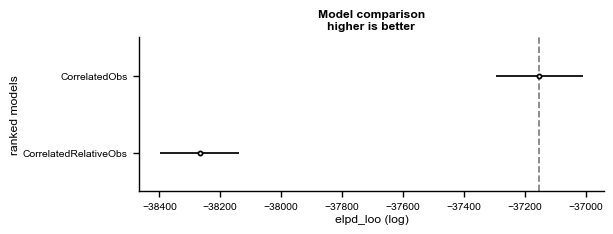

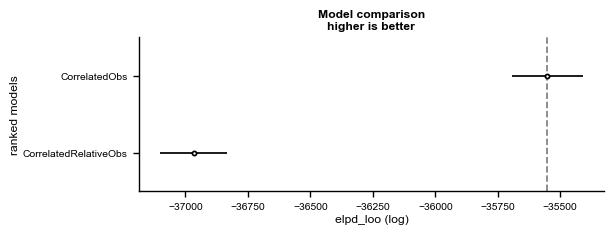

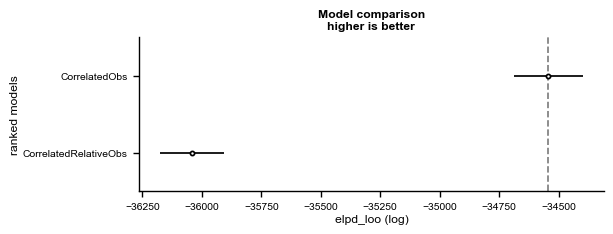

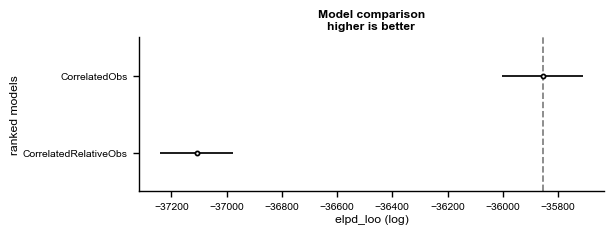

In [2]:
positions = [[12, 12], [12, 22], [22, 12], [22, 22]]

summaries = []

for pos in positions:
    models = {"CorrelatedObs": az.from_netcdf(f"results/mcmc-{pos}-CorrelatedObservationBoundedActor-1.nc"),
            "CorrelatedRelativeObs": az.from_netcdf(f"results/mcmc-{pos}-CorrelatedRelativeObservationBoundedActor-1.nc")
    }

    for model_name, model in models.items():
        summary = az.summary(model)
        summary["pos"] = str(pos)
        summary["model"] = model_name
        summaries.append(summary)

    comparison = az.compare(models)
    az.plot_compare(comparison)

## Visualize parameter estimates

In [3]:
df = pd.concat(summaries)
df = df.reset_index().rename(columns={"index":'param'})


df["param"] = df["param"].map(lambda x: x.replace("0", "x").replace("1", "y"))
df["r_hat"]

0     NaN
1     NaN
2     1.0
3     1.0
4     1.0
     ... 
91    1.0
92    1.0
93    1.0
94    1.0
95    1.0
Name: r_hat, Length: 96, dtype: float64

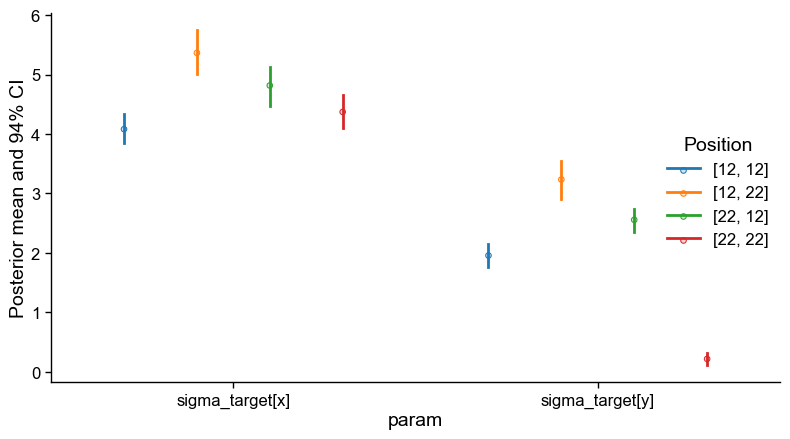

In [9]:
g = (
    so.Plot(
        df[(df["param"].str.contains("sigma_target")) & (df["model"] == "CorrelatedObs")],
        x="param",
        y="mean",
        ymin="hdi_3%",
        ymax="hdi_97%",
        color="pos"
    )
    .add(so.Dots(), so.Dodge())
    .add(so.Range(), so.Dodge())
    .label(y="Posterior mean and 94% CI", color="Position")
    .theme(mpl.rcParams)
    .layout(size=(8, 4.5))
)

g.show()


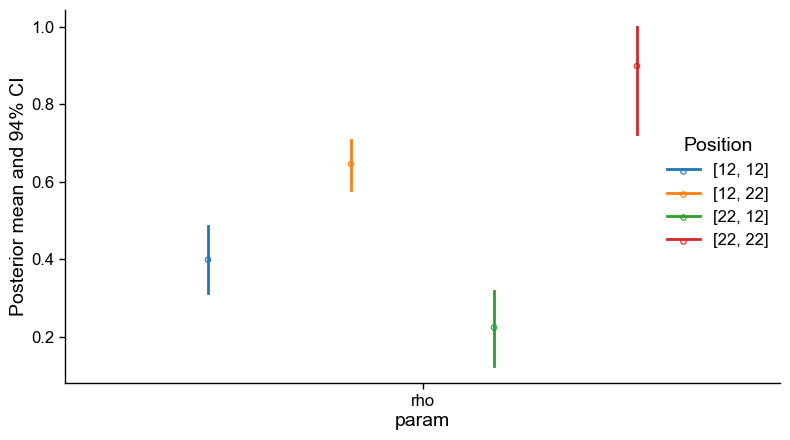

In [11]:
g = (
    so.Plot(
        df[(df["param"].str.contains("rho")) & (df["model"] == "CorrelatedObs")],
        x="param",
        y="mean",
        ymin="hdi_3%",
        ymax="hdi_97%",
        color="pos"
    )
    .add(so.Dots(), so.Dodge())
    .add(so.Range(), so.Dodge())
    .label(y="Posterior mean and 94% CI", color="Position")
    .theme(mpl.rcParams)
    .layout(size=(8, 4.5))
)

g.show()
